### About Dataset

• Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs.

#### Data Loading

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.shape

# can use (r'E:\Projects\Telco-Customer-Churn-MLE\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv') -- r = real string

(7043, 21)

In [7]:
for col in df.columns:
    uniq=df[col].unique()
    if len(uniq)==4:
        print(f"columns : {col}")
        print(f"values : {list(uniq)}")
    

columns : PaymentMethod
values : ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']


In [191]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [192]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


• Based on the .describe, we can see most categorical variables have 2, 3 or 4 categories.

• For the categories that have 2 (binary) values, lets replace by 0 and 1 (Binary Encoding).

• For those having 3 or 4 categories, we can do One-Hot Encoding.

#### Binary Encoding

In [193]:
# Binary categorical values having 2 unique values
binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling','Churn']

# Mapping Yes/No and Male/Female to 0/1
df[binary_cols] = df[binary_cols].replace({
    'Yes':1, 'No':0,
    'Male':1, 'Female':0
})

C:\Users\Dell\AppData\Local\Temp\ipykernel_2064\3829158788.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({


In [194]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


#### One-Hot Encoding

###### One-hot encoding is a way to convert categorical (text) data into numbers so machine learning models can understand it. A model cannot understand "Red" or "Blue" — it needs numbers.

In [195]:
# Categorical columns with >2 unique values

multi_cat_cols = [
    'MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
    'Contract','PaymentMethod'
    ]

df = pd.get_dummies(df, columns = multi_cat_cols, drop_first=True)

# drop_first is used in one-hot encoding to avoid creating redundant dummy columns

In [196]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.5,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


#### Cleaning

In [197]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# coerce : If any value cannot be converted to a number, replace it with NaN instead of throwing an error. Also coverts object/string to int/float

In [198]:
df = df.drop('customerID', axis = 1)

In [199]:
# Selecting all the boolean columns
bool_cols = df.select_dtypes(include='bool').columns

# Converts True/False to 1/0 for all boolean columns
df[bool_cols] = df[bool_cols].astype(int)

In [200]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  Mult

                                          Churn
Churn                                  1.000000
InternetService_Fiber optic            0.308020
PaymentMethod_Electronic check         0.301919
MonthlyCharges                         0.193356
PaperlessBilling                       0.191825
SeniorCitizen                          0.150889
StreamingTV_Yes                        0.063228
StreamingMovies_Yes                    0.061382
MultipleLines_Yes                      0.040102
PhoneService                           0.011942
gender                                -0.008612
MultipleLines_No phone service        -0.011942
DeviceProtection_Yes                  -0.066160
OnlineBackup_Yes                      -0.082255
PaymentMethod_Mailed check            -0.091683
PaymentMethod_Credit card (automatic) -0.134302
Partner                               -0.150448
Dependents                            -0.164221
TechSupport_Yes                       -0.164674
OnlineSecurity_Yes                    -0

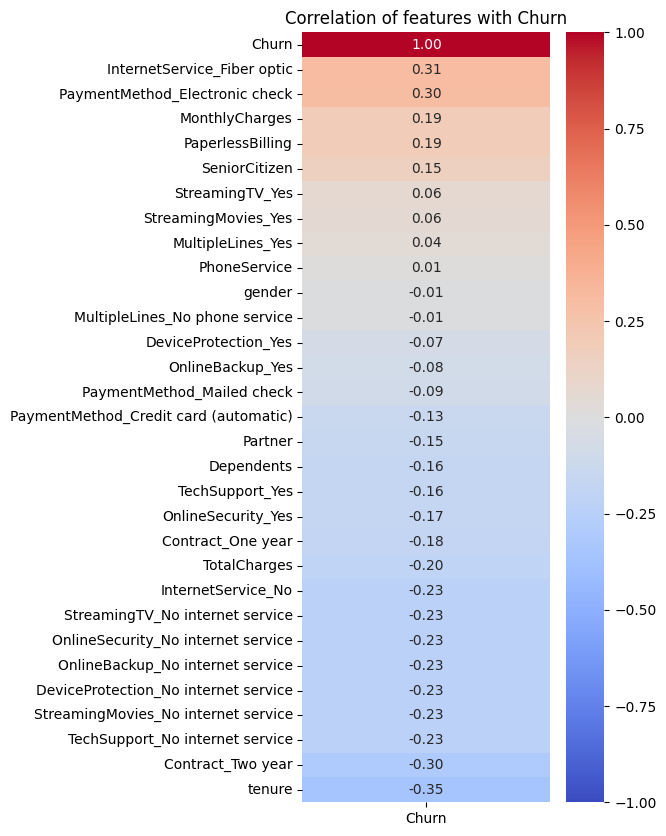

In [201]:
# Correlation Values

corr_matrix = df.corr(numeric_only=True)
churn_corr = corr_matrix[['Churn']].sort_values(by='Churn', ascending=False)
print(churn_corr)

# Find correlation between all numeric features and the target (Churn), and rank them from strongest to weakest

#Plot Heatmap

plt.figure(figsize=(4,10))
sns.heatmap(churn_corr, annot=True, cmap = 'coolwarm', fmt=".2f",vmin=-1, vmax=1)
plt.title('Correlation of features with Churn')
plt.show()

# vmin → minimum value of the color scale
# vmax → maximum value of the color scale

##### Negative (lower value -> less likely to churn)

###### • tenure (-0.35) -> Customers who stay longer are less likely to depart/churn due to negative experience, dissatisfaction...
###### • Contract_Two year (-.30) -> Customers on long-term contracts churn much less.
###### • Contract_One year (-0.18) -> Same trend but weaker than two-year contracts.

##### Postive (higher value -> more likely to churn)

###### • InternetService_Fiber optic (+0.31) → Fiber optic users churn more in this dataset.
###### • PaymentMethod_Electronic check (+0.30) → Customers paying via electronic check churn more.

*****************************
#### Multicollinearity (VIF)

##### Multicollinearity happens when two or more independent variables are highly correlated (related to each other), making it difficult to accurately determine the unique effect of each predictor, causing redundancy. Both the features gives the same information.

For eg: Two scientist with same skillset invents something. The contribution of both the scientists will be hard to determine than the scientists with a vareity of skillset

In [202]:
# Needs to collapse the redundant columns before running VIF
# This line is creating a new feature called No_internet_service by combining several existing columns
df['No_internet_service'] = (
    df['OnlineSecurity_No internet service'] |
    df['OnlineBackup_No internet service'] |
    df['DeviceProtection_No internet service'] |
    df['TechSupport_No internet service'] |
    df['StreamingTV_No internet service'] |
    df['StreamingMovies_No internet service']
).astype(int)

## Drop the original redundant dummies

drop_cols = [col for col in df.columns if 'No internet service' in col]
df = df.drop(columns=drop_cols)

# This code creates a single feature that flags whether a customer has no internet service by combining multiple related dummy variables.

# remove “No internet/phone service” dummy columns because they represent duplicate signal of: PhoneService / InternetService = No
if 'MultipleLines_No phone service' in df.columns:
    df['No_phone_service'] = df['MultipleLines_No phone service'].astype(int)
    df = df.drop(columns = ['MultipleLines_No phone service'])

In [203]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,No_internet_service,No_phone_service
0,0,0,1,0,1,0,1,29.85,29.85,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0
2,1,0,0,0,2,1,1,53.85,108.15,1,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0
3,1,0,0,0,45,0,0,42.30,1840.75,0,0,0,0,1,0,1,1,0,0,1,0,0,0,0,0,1
4,0,0,0,0,2,1,1,70.70,151.65,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [204]:
# X contains only input features because VIF is computed only on features.

X = df.drop(columns='Churn')
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols]=X[bool_cols].astype(int)

# ensured all boolean features were converted to numeric form before computing VIF, since the function requires purely numerical input.

In [205]:
# Run VIF : VIF measures how much a feature can be predicted by other features using R², and higher values indicate redundancy

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Remove rows with missing or infinite values
X = X.replace([np.inf,-np.inf], np.nan)
X = X.dropna()

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values,i) for i in range(len(X.columns))]
vif_data = vif_data.sort_values(by='VIF',ascending=False)

print(vif_data)


e:\Projects\Telco-Customer-Churn-MLE\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                                  feature          VIF
11                     InternetService_No          inf
23                    No_internet_service          inf
5                            PhoneService  1773.528816
7                          MonthlyCharges   866.089640
10            InternetService_Fiber optic   148.500814
24                       No_phone_service    60.842267
17                    StreamingMovies_Yes    24.156394
16                        StreamingTV_Yes    24.080019
8                            TotalCharges    10.811490
4                                  tenure     7.584453
9                       MultipleLines_Yes     7.289761
14                   DeviceProtection_Yes     6.924754
13                       OnlineBackup_Yes     6.796678
15                        TechSupport_Yes     6.476508
12                     OnlineSecurity_Yes     6.338349
19                      Contract_Two year     2.652328
21         PaymentMethod_Electronic check     1.976032
22        

We can see there's multiocollinearity between features, we can drop the features with high multicollinearity or we can use regularization techniques.

We can use tree based models which are less sensitive to multicollinearity. They do not assume a linear relationship between predictors and the target, and they select features based on their ability to split the data effectively. If two features are highly correlated, the tree will typically choose one for a split and ignore the other, as including both does not improve impurity reduction. In decision trees, splits are based on feature importance for reducing impurity — redundant features just compete, but won’t cause unstable predictions.

#### Machine Learning

In [206]:
# There's a class imbalance issue.
#  27% are churners

df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In churn prediction, recall is usually the most important.

Business Perspecive:
1) False-Negative(FN) - You predict the customer will not churn, but they actually leave the company->you miss the chance to intervene and keep them.
2) False-Positive (FP) - YOu predict the customer will churn, but they stay -> you might spend some retention resources unnecessarily.
3) Missing churners(FN) usually cost more than wrongly targetting a loyal customer.

Major Priority:
1) If rentention campaigns are cheap, prioritize recall (catch every possible churners).
2) If rentention campaigns are expensive, balance precision and recall using F1 score or precision-recall trade off.
3) If business wants a ranking of churn risk, use ROC-AUC or PR-AUC to evaluate the model



In [207]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import classification_report
import time

#Prepare data
X = df.drop(columns='Churn')
y = df['Churn']

#Train-test-split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

THRESHOLD = 0.3 # lower than 0.5 to boost recall

# In churn/fraud: Missing positives is costly So lower threshold: Increases recall, Detects more churners

#### Random Forest Classification

In [208]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',  #handles imbalance
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

proba = rf.predict_proba(X_test)[:,1]
y_pred = (proba>=THRESHOLD).astype(int)

print(classification_report(y_test,y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.883     0.771     0.823      1035
           1      0.531     0.717     0.610       374

    accuracy                          0.757      1409
   macro avg      0.707     0.744     0.716      1409
weighted avg      0.789     0.757     0.766      1409



Threshold-Tuning of Random Forest Classifier

In [209]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = rf.predict_proba(X_test)[:, 1]

print("Threshold tuning for RandomForest")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds)   # Among predicted churns, how many were truly churn?
    rec = recall_score(y_test, preds)       # Among actual churns, how many did we catch?
    f1 = f1_score(y_test, preds)
    print(f"{thresh:<8.2f}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for RandomForest
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.508   0.797   0.620   
0.30    0.531   0.717   0.610   
0.35    0.548   0.668   0.602   
0.40    0.571   0.615   0.592   
0.45    0.601   0.551   0.575   
0.50    0.625   0.489   0.549   


Instead of using the default 0.5 threshold, I tuned the classification threshold using predicted probabilities and evaluated precision, recall, and F1-score to optimize churn detection performance.

With a threshold of 0.3, You’re now catching 71.7% of actual churners with RandomForest

#### LightGBM

In [210]:
# All boosting algorithms work on the basis of learning from the rrors of the previous model trained and tried avoiding the same mistakes 
# made by the previously trained weak learning algorithm

from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

#Training timer
start_train = time.time()
lgbm.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"Training time: {train_time:.2f} seconds")

#Prediction time
start_pred = time.time()
proba = lgbm.predict_proba(X_test)[:,1]
y_pred = (proba>=THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"Prediction time: {pred_time:.4f} seconds")

print(classification_report(y_test, y_pred, digits=3))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004328 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 627
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training time: 0.88 seconds
Prediction time: 0.0221 seconds
              precision    recall  f1-score   support

           0      0.914     0.702     0.795      1035
           1      0.498     0.818     0.619       374

    accuracy                          0.733      1409
   macro avg      0.706     0.760     0.707      1409
weighted avg      0.804     0.733   

We are now catching ~82% of actual churners with LightBGM (improvement)

• The cost is a small drop in precision that means more loyal customers will be flagged as churners, but if retention offers are low-cost, this is fine.

Threshold-Tuning of LightBGM

In [211]:
proba = lgbm.predict_proba(X_test)[:,1]

print("Threshold-Tuning of LightBGM")

print(f"{'Thresh':<10}{'Prec_1':<10}{'Rec_1':<10}{'F1_1':<10}")
for thresh in [0.25,0.30,0.35,0.40,0.45,0.50]:
    preds = (proba>=thresh).astype(int)
    prec = precision_score(y_test,preds)
    rec = recall_score(y_test,preds)
    f1 = f1_score(y_test, preds)
    print(f"{thresh:<10.2f}{prec:<10.3f}{rec:<10.3f}{f1:<10.3f}")

Threshold-Tuning of LightBGM
Thresh    Prec_1    Rec_1     F1_1      
0.25      0.479     0.842     0.610     
0.30      0.498     0.818     0.619     
0.35      0.507     0.786     0.616     
0.40      0.524     0.757     0.619     
0.45      0.537     0.741     0.622     
0.50      0.552     0.701     0.617     


#### XGBoost

In [212]:
# XGBoost is an optimized implementation of gradient boosting that uses sequential tree learning with reglarization (improves
# on new unseen data) and parallel computation for high performance ML

from xgboost import XGBClassifier

scale_pos_weight = (y_train==0).sum() / (y_train==1).sum()

xgb = XGBClassifier(
    n_estimators=500,      #more trees, more patterns, But increases training time
    learning_rate=0.05,
    max_depth=6,           #How deep each tree can grow. Small depth = Simpler model, Laege depth = Risk of memorizing data (Overfitting)
    subsample=0.8,         #using 80% training rows for each tree, adds randomness so that each tree can work with variety of data
    colsample_bytree=0.8,  #each tree only sees 80% of the features, prevents reliance on a few dominant features
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'  # logloss measures probability quality. After each tree, XGBoost computes logarithmic loss on validation data.
)

#Training time
start_train = time.time()
xgb.fit(X_train,y_train)
train_time = time.time() - start_train
print(f"Training time: {train_time:.2f} seconds")

#Prediction Time
start_pred = time.time()
proba = xgb.predict_proba(X_test)[:,1]
y_pred = (proba>=THRESHOLD).astype(int)
prediction_time = time.time() - start_pred
print(f"Prediction TIme :{prediction_time:.4f} seconds")

print(classification_report(y_test,y_pred, digits=3))


Training time: 0.70 seconds
Prediction TIme :0.0158 seconds
              precision    recall  f1-score   support

           0      0.909     0.687     0.783      1035
           1      0.483     0.810     0.605       374

    accuracy                          0.720      1409
   macro avg      0.696     0.749     0.694      1409
weighted avg      0.796     0.720     0.736      1409



In [213]:
proba = xgb.predict_proba(X_test)[:,1]

print("Threshold-Tuning for XGboost Classifier")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25,0.3,0.35,0.4,0.45,0.5]:
    preds = (proba>=thresh).astype(int)
    prec = precision_score(y_test,preds)
    rec = recall_score(y_test,preds)
    f1 = f1_score(y_test,preds)
    print(f"{thresh:<8.2f}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")
    

Threshold-Tuning for XGboost Classifier
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.465   0.834   0.597   
0.30    0.483   0.810   0.605   
0.35    0.505   0.789   0.616   
0.40    0.518   0.770   0.619   
0.45    0.527   0.735   0.614   
0.50    0.549   0.698   0.615   


ML Model Choice - XGBoost

Recall - Same as LightGBM but generally faster training/prediction time

#### Hyper-Parameter Tuning

In [214]:
# Optuna automatically searches for best parameters. A single Optuna experiment is called a trial.

import optuna

#Objective function for Optuna

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators",300,800),
        "learning_rate": trial.suggest_float("learning_rate",0.01,0.2),
        "max_depth": trial.suggest_int("max_depth",3,10),
        "subsample": trial.suggest_float("subsample",0.5,1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree",0.5,1.0),
        "min_child_weight": trial.suggest_int("min_child_weight",1,10),
        "gamma": trial.suggest_float("gamma",0,5),
        "reg_alpha": trial.suggest_float("reg_alpha",0,5),
        "reg_lambda": trial.suggest_float("reg_lambda",0,5),
        "random_state": 42,
        "n_jobs": -1,
        "eval_metric": "logloss",
        "scale_pos_weight": (y_train==0).sum() / (y_train==1).sum()
    }
    
    model = XGBClassifier(**params)
    model.fit(X_train,y_train)
    proba = model.predict_proba(X_test)[:,1]
    y_pred = (proba>=THRESHOLD).astype(int)
    return recall_score(y_test, y_pred)

#Running Optuna

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("Best Params: ", study.best_params)
print("Best Recall: ", study.best_value)

[I 2026-05-18 00:22:26,232] A new study created in memory with name: no-name-bca6ac78-fae8-4df7-8983-fa9fdf7a4b2d
[I 2026-05-18 00:22:26,535] Trial 0 finished with value: 0.893048128342246 and parameters: {'n_estimators': 348, 'learning_rate': 0.06671702968591728, 'max_depth': 5, 'subsample': 0.9246374789317373, 'colsample_bytree': 0.8706170785719822, 'min_child_weight': 2, 'gamma': 2.612983814429994, 'reg_alpha': 0.839728622442491, 'reg_lambda': 3.840068633485328}. Best is trial 0 with value: 0.893048128342246.
[I 2026-05-18 00:22:26,975] Trial 1 finished with value: 0.8983957219251337 and parameters: {'n_estimators': 432, 'learning_rate': 0.08461069870907599, 'max_depth': 6, 'subsample': 0.7557882195892547, 'colsample_bytree': 0.8631863673134645, 'min_child_weight': 2, 'gamma': 2.9080392438412863, 'reg_alpha': 4.0580554742890556, 'reg_lambda': 3.437158671866812}. Best is trial 1 with value: 0.8983957219251337.
[I 2026-05-18 00:22:27,459] Trial 2 finished with value: 0.906417112299465

Best Params:  {'n_estimators': 651, 'learning_rate': 0.058726710541211834, 'max_depth': 3, 'subsample': 0.9953343726172407, 'colsample_bytree': 0.5017251774954158, 'min_child_weight': 7, 'gamma': 4.431699500096039, 'reg_alpha': 3.3305995671610384, 'reg_lambda': 0.6605806375401291}
Best Recall:  0.9251336898395722


In [215]:
scale_pos_weight = (y_train==0).sum() / (y_train==1).sum()

best_params = study.best_params
best_params.update({
    'random_state': 42,
    'n_jobs': -1,
    'scale_pos_weight': scale_pos_weight,
    'eval_metric': 'logloss'
})

# Creating model from best params
xgb = XGBClassifier(**best_params)

#Training time
start_train = time.time()
xgb.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"Training time: {train_time:.2f} seconds")

#Prediction time
start_pred = time.time()
proba = xgb.predict_proba(X_test)[:,1]
y_pred = (proba>=THRESHOLD).astype(int)
pred_time= time.time() - start_pred
print(f"Prediction time: {pred_time:.4f} seconds")

print(classification_report(y_test, y_pred))



Training time: 0.55 seconds
Prediction time: 0.0117 seconds
              precision    recall  f1-score   support

           0       0.95      0.56      0.71      1035
           1       0.43      0.93      0.59       374

    accuracy                           0.66      1409
   macro avg       0.69      0.74      0.65      1409
weighted avg       0.82      0.66      0.68      1409



-----------------------------------------------------------
Recall (Class 1) : 93% -- catching almost all churners

Precision (Class 1) : 43% -- many loyal customers are flagged.

Recall increased from 81% to 93% (13%). This model catches almost all the churners, which is great if you're running aggressive retention campaigns
